In [1]:
from utils.binaries import *
from utils.plotting import *

15:52:49 (+3854.2s) [INFO   ] -- import logging


15:52:49 (  +201ms) [INFO   ] -- import numpy as np
15:52:49 (    +5ms) [INFO   ] -- import uncertainties
15:52:49 (    +5ms) [INFO   ] -- import uncertainties
15:52:50 (  +457ms) [INFO   ] -- import pandas as pd
15:52:50 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
15:52:50 (    +1ms) [INFO   ] -- import binaries.tools as tools
15:52:50 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
15:52:50 (    +0ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
15:52:50 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
15:52:50 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
15:52:50 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
15:52:50 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
15:52:50 (  +337ms) [INFO   ] -- import matplotlib.pyplot as plt
15:52:50 (  +543ms) [INFO   ] -- import 

In [75]:
olo_x, olo_y = np.loadtxt("olomouc.csv", delimiter=',', unpack=True)
kit_x, kit_y = np.loadtxt("kit_results.txt", unpack=True)

l = uncertainties.ufloat(365e-9, 5e-9)      # m
h = 6.62607015e-34                          # m² kg / s
c = 299_792_458                             # m / s

In [33]:
from scipy.optimize import curve_fit

def inverse_view_factor(z, offset, r=0, R=0):

    z = z - offset
    a, b = R/z, r/z
    x = 1 + np.pow(a, -2) + np.pow(b/a, 2)
    y = np.sqrt(np.pow(x, 2) - 4 * np.pow(b/a, 2))

    return 0.5 * (x - y)

popt_olo, pcov_olo = curve_fit(inverse_view_factor, olo_x, olo_y * 1e9, p0=[-71.51005019,  17.15558746,  26.69643487])
popt_kit, pcov_kit = curve_fit(inverse_view_factor, kit_x, kit_y)

17:45:34 ( +152.2s) [DEBUG  ] -- font size set to 9.5
17:45:34 (    +1ms) [DEBUG  ] -- label size set to 13.0
17:45:34 (    +2ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
17:45:34 (    +1ms) [DEBUG  ] -- markersize set to 2.0
17:45:34 (    +0ms) [DEBUG  ] -- usetex set to False


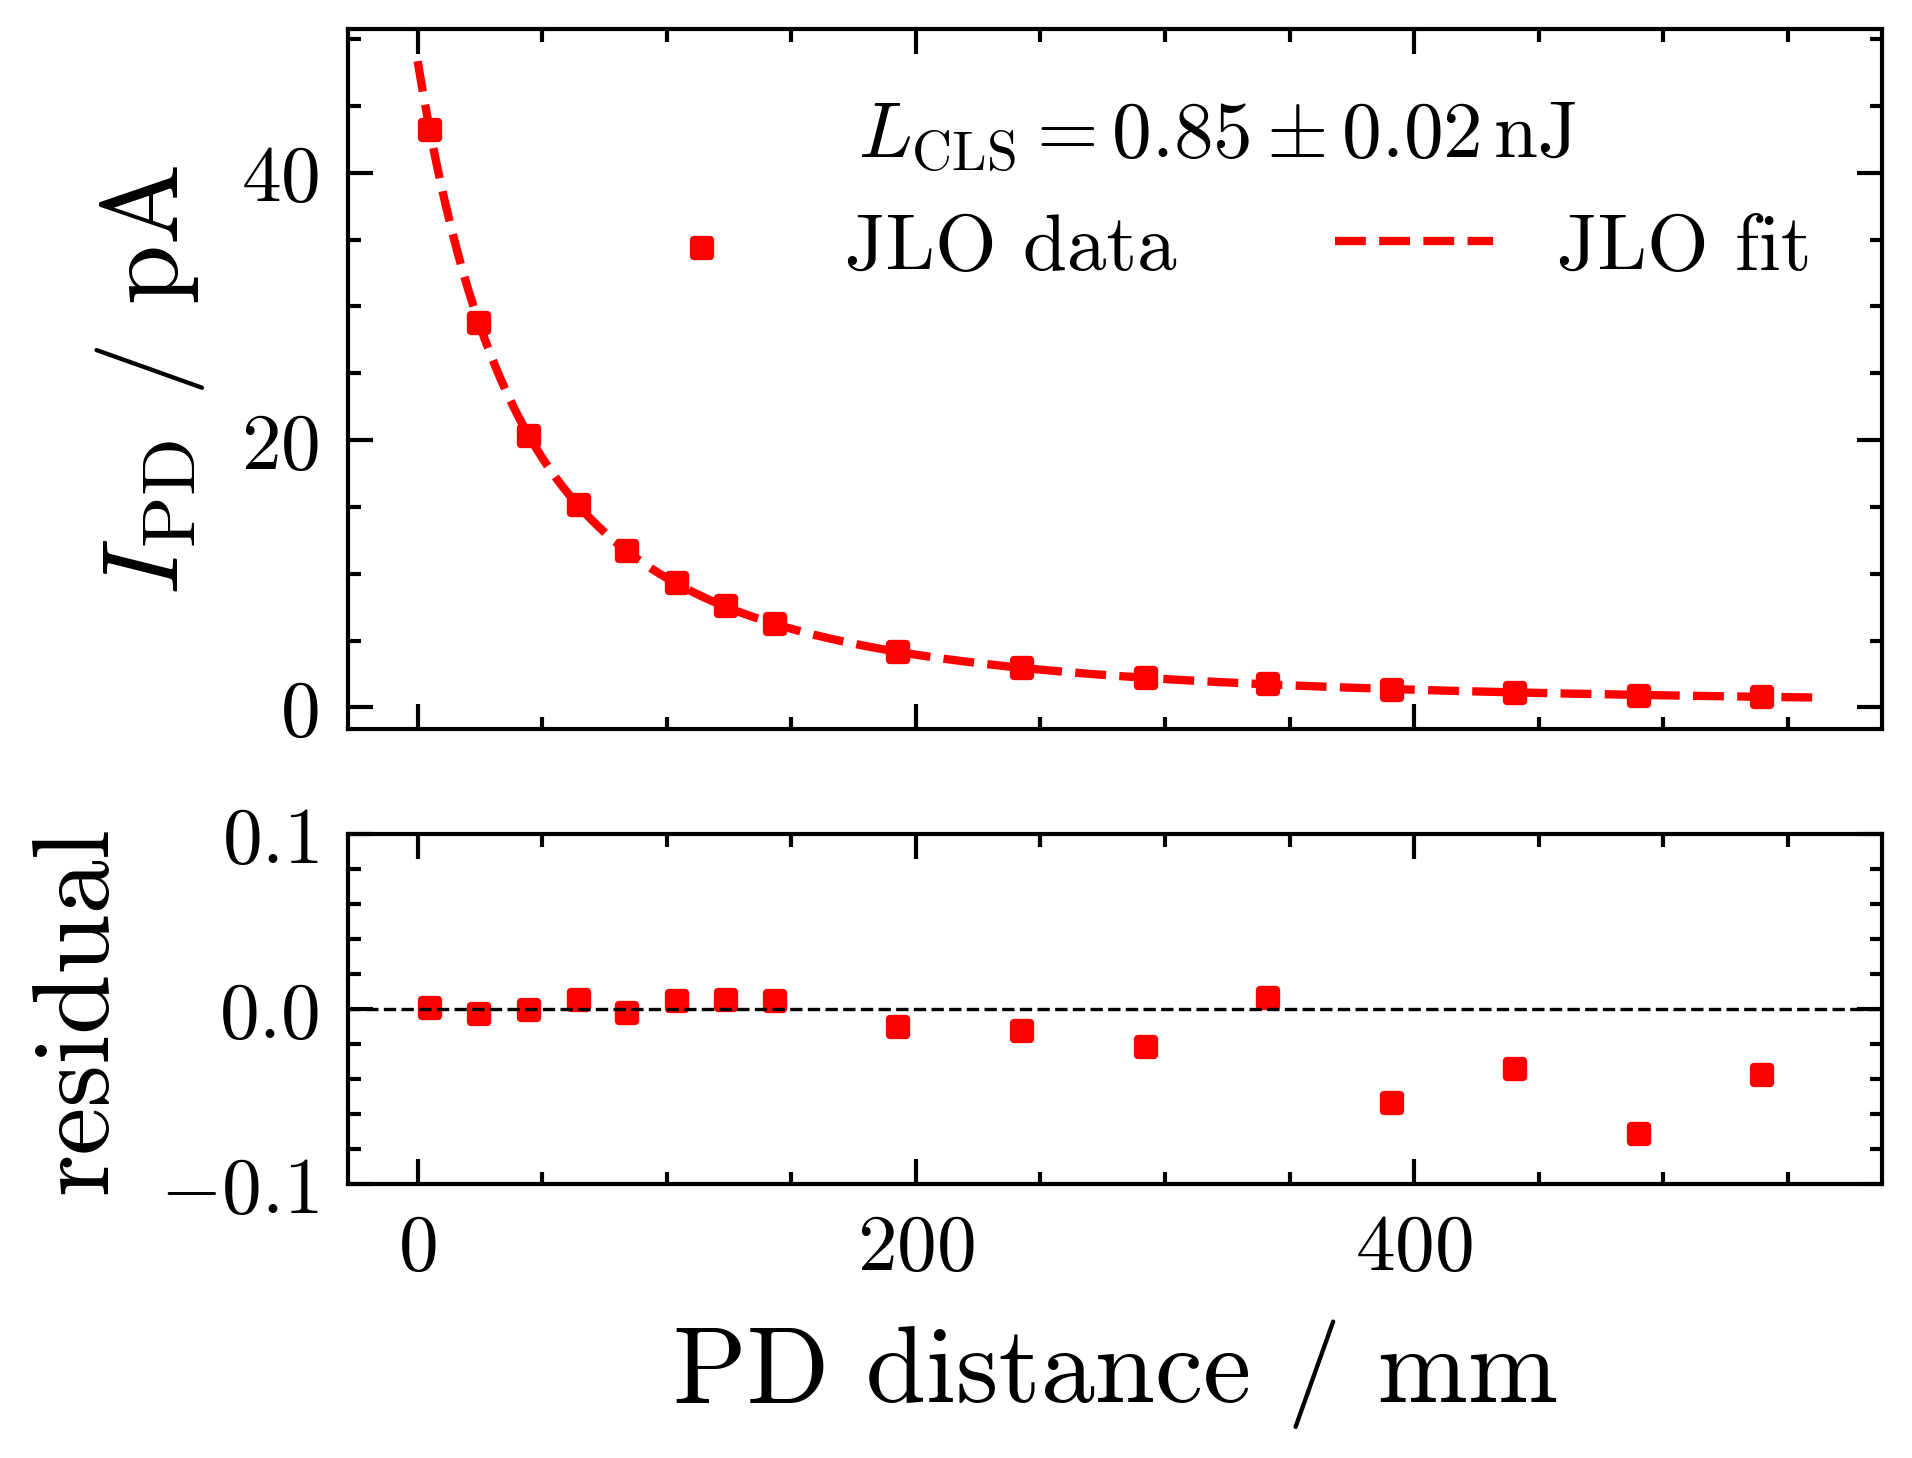

In [85]:
set_plt_style("double")

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.5], sharex=True)

X = np.linspace(0, 560, 500)

ax1.scatter(olo_x, olo_y * 1e12, label="JLO data", marker='s', c='r')
ax1.plot(X, inverse_view_factor(X, *popt_olo) * 1e3, marker='none', label="JLO fit", c='r', ls='--')

ax1.set_ylabel(r"$I_\mathrm{PD}$ / pA")
ax2.set_ylabel(r"residual")
ax2.set_xlabel(r"PD distance / mm")

ax2.scatter(olo_x, (olo_y * 1e9 - inverse_view_factor(olo_x, *popt_olo))/inverse_view_factor(olo_x, *popt_olo), marker='s', c='r')

n_gamma_olo = uncertainties.ufloat(1.555e9, 0.029e9)
l_src_olo = n_gamma_olo * h * c / l

ax1.legend(ncol=2, title=f'$L_\mathrm{{CLS}} = {l_src_olo.nominal_value*1e9:.2f}\pm{l_src_olo.std_dev*1e9:.2f}\,\mathrm{{nJ}}$')
# axt = ax1.twinx()
# axt.set_ylim(*ax1.get_ylim())
# axt.set_yticklabels([])
# axt.plot([], [], c='w', label=' ', alpha=0)
# axt.legend()

ax2.set_ylim(-0.1, 0.1)
ax2.axhline(0, c='k', ls='--', lw=0.4)
# plt.yscale("log")

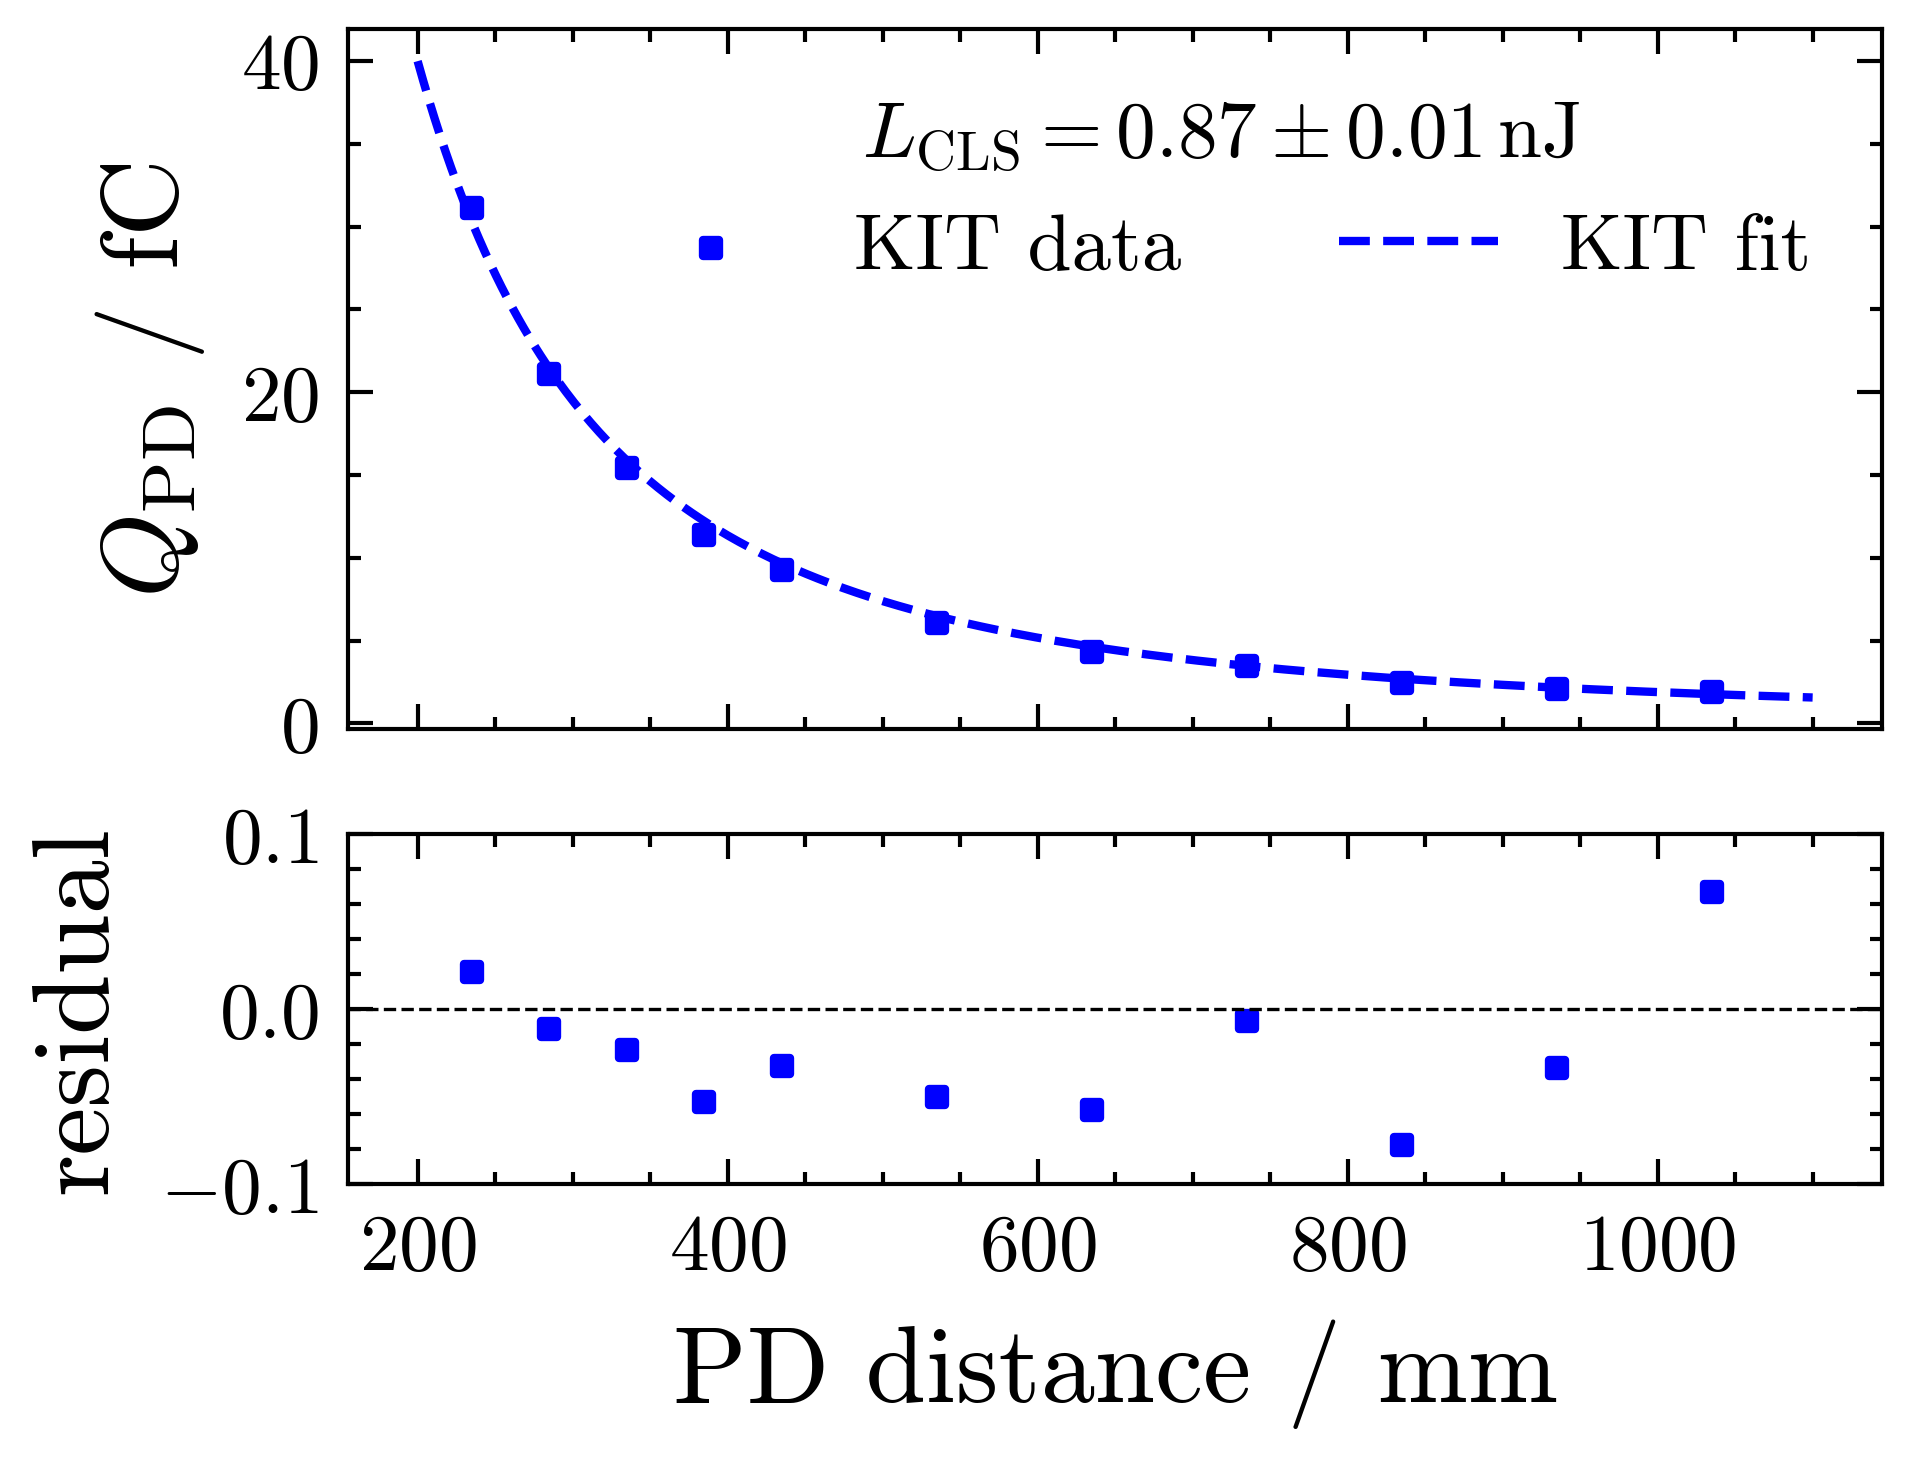

In [86]:
fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.5], sharex=True)

X = np.linspace(200, 1100, 500)

ax1.scatter(kit_x * 1000, kit_y, label="KIT data", marker='s', c='b')
ax1.plot(X, 270*inverse_view_factor(X, *popt_kit), label="KIT fit", marker='none', c='b', ls='--')

ax1.set_ylabel(r"$Q_\mathrm{PD}$ / fC")
ax2.set_ylabel(r"residual")
ax2.set_xlabel(r"PD distance / mm")

ax2.scatter(kit_x * 1000, 0.8*(kit_y - 270*inverse_view_factor(kit_x*1000, *popt_kit)) \
            / (270*inverse_view_factor(kit_x*1000, *popt_kit)), marker='s', c='b')

n_gamma_kit = uncertainties.ufloat(1.595e9, 0.014e9)
l_src_kit = n_gamma_kit * h * c / l

ax1.legend(ncol=2, title=f'$L_\mathrm{{CLS}} = {l_src_kit.nominal_value*1e9:.2f}\pm{l_src_kit.std_dev*1e9:.2f}\,\mathrm{{nJ}}$')

ax2.set_ylim(-0.1, 0.1)
ax2.axhline(0, c='k', ls='--', lw=0.4)
# plt.yscale("log")

In [52]:
270*inverse_view_factor(kit_x*1000, *popt_kit)

array([30.28655331, 21.41697637, 15.87506031, 12.20704382,  9.66397402,
        6.4732852 ,  4.6294967 ,  3.4715778 ,  2.69815756,  2.15649293,
        1.76263831])

In [61]:
(kit_y - 270*inverse_view_factor(kit_x*1000, *popt_kit)) / (270*inverse_view_factor(kit_x*1000, *popt_kit))

array([ 0.02693957, -0.01425001, -0.02878647, -0.06594853, -0.04078372,
       -0.06293063, -0.07159556, -0.00868181, -0.09683363, -0.04197879,
        0.0839356 ])